In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfilt

import sys
sys.path.append('../../')
import analysis_utils as utils
import calc_gas_collision_spectrum as calc_gas

utils.load_plotting_setting()

In [4]:
import os
import glob
import scipy.io

DATA_DIR = '/Volumes/LaCie/electric_feedback/sphere_20260215'

# Collect all 20260305_d_* folders, sorted by label
folder_names = sorted([
    d for d in os.listdir(DATA_DIR)
    if d.startswith('20260305_d_') and os.path.isdir(os.path.join(DATA_DIR, d))
])

# Define a sort key to order by dB level where possible
def sort_key(name):
    tag = name.replace('20260305_d_', '')
    if tag == 'pllonly':
        return (1, 0, 0)
    if tag.startswith('pll_'):
        db_str = tag.replace('pll_', '').replace('db', '')
        return (2, float(db_str), 0)
    parts = tag.replace('db', '').split('_')
    vals = [float(p) for p in parts if p]
    return (0, vals[0], vals[1] if len(vals) > 1 else 0)

folder_names = sorted(folder_names, key=sort_key)

for fn in folder_names:
    mats = sorted(glob.glob(os.path.join(DATA_DIR, fn, '*.mat')))
    print(f'{fn}: {len(mats)} files')

20260305_d_-40db: 5 files
20260305_d_-30db: 5 files
20260305_d_-20db: 5 files
20260305_d_-10db: 5 files
20260305_d_0db: 5 files
20260305_d_10db: 5 files
20260305_d_10db_40db: 5 files
20260305_d_20db: 5 files
20260305_d_30db: 5 files
20260305_d_40db: 5 files
20260305_d_pllonly: 5 files
20260305_d_pll_-40db: 5 files


In [5]:
def load_mat_channel(filepath):
    """Load D channel from a .mat file, returning (dt, data_1d)."""
    d = scipy.io.loadmat(filepath)
    dt = float(d['Tinterval'].ravel()[0])
    data = d['D'].ravel().astype(np.float64)
    return dt, data


# Compute PSD for each folder using only the first file
NPERSEG = 2**18  # ~52 ms segments at 5 MHz

psds = {}   # folder_name -> (ff, pp)

for fn in folder_names:
    mat_files = sorted(glob.glob(os.path.join(DATA_DIR, fn, '*.mat')))
    dt, zz = load_mat_channel(mat_files[0])
    ff, pp = utils.get_psd(dt=dt, zz=zz, nperseg=NPERSEG)
    psds[fn] = (ff, pp)
    print(f'Done: {fn}')

Done: 20260305_d_-40db
Done: 20260305_d_-30db
Done: 20260305_d_-20db
Done: 20260305_d_-10db
Done: 20260305_d_0db
Done: 20260305_d_10db
Done: 20260305_d_10db_40db
Done: 20260305_d_20db
Done: 20260305_d_30db
Done: 20260305_d_40db
Done: 20260305_d_pllonly
Done: 20260305_d_pll_-40db


In [6]:
CAL_DIR = '/Volumes/LaCie/electric_feedback/sphere_20260215/20260305_electric_calibration_3e-8mbar_0'
CAL_PREFIX = '20260305_d_p5e_117khz'
CAL_SUFFIX = 'lensholder1'
VPPS = [0.5, 1, 1.5, 2]

c_mvs_all = []
for vpp in VPPS:
    files = sorted(glob.glob(os.path.join(CAL_DIR, f'{CAL_PREFIX}_{vpp}vpp_{CAL_SUFFIX}_*.hdf5')))
    c_mv_arr = utils.get_c_mv(
        files,
        vp2p=[vpp] * len(files),
        omegad=117000 * 2 * np.pi,
        passband=(116900, 117100),
        searchband=(38000, 75000),
        charge=5,
        efield=138,
        sphere_radius=50e-9,
        n_chunk=1,
    )
    c_mvs_all.append(c_mv_arr)
    print(f'{vpp} Vpp: c_mv = {np.mean(c_mv_arr):.4e} m/V')

c_mv = np.mean(np.asarray(c_mvs_all))
print(f'\nMean c_mv = {c_mv:.4e} m/V')

0.5 Vpp: c_mv = 8.2671e-07 m/V
1 Vpp: c_mv = 5.0829e-07 m/V
1.5 Vpp: c_mv = 5.1387e-07 m/V
2 Vpp: c_mv = 5.1855e-07 m/V

Mean c_mv = 5.9185e-07 m/V


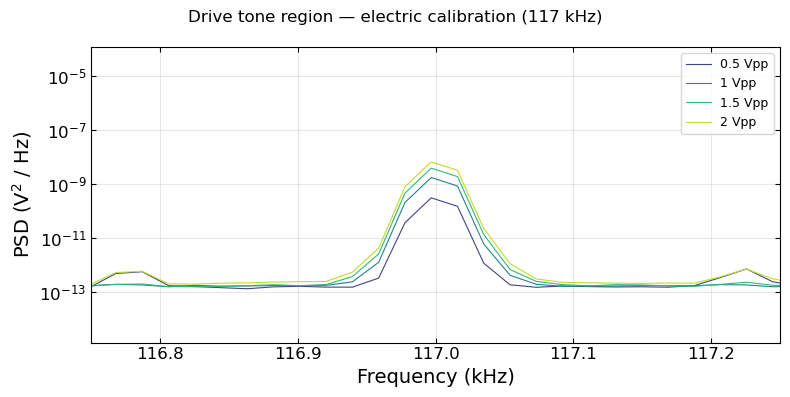

In [7]:
# Plot PSD near 117 kHz drive tone for one file per voltage, to guide passband choice
fig, ax = plt.subplots(figsize=(8, 4))

colors_cal = plt.colormaps['viridis'](np.linspace(0.2, 0.9, len(VPPS)))
for i, vpp in enumerate(VPPS):
    files = sorted(glob.glob(os.path.join(CAL_DIR, f'{CAL_PREFIX}_{vpp}vpp_{CAL_SUFFIX}_*.hdf5')))
    dtt, nn = utils.load_timestreams(files[0], ['D'])
    ff, pp = utils.get_psd(dt=dtt, zz=nn[0], nperseg=2**18)
    ax.semilogy(ff / 1e3, pp, lw=0.8, label=f'{vpp} Vpp', color=colors_cal[i])

ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('PSD (V$^2$ / Hz)')
ax.set_xlim(116.75, 117.25)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
fig.suptitle('Drive tone region — electric calibration (117 kHz)')
fig.tight_layout()
plt.show()

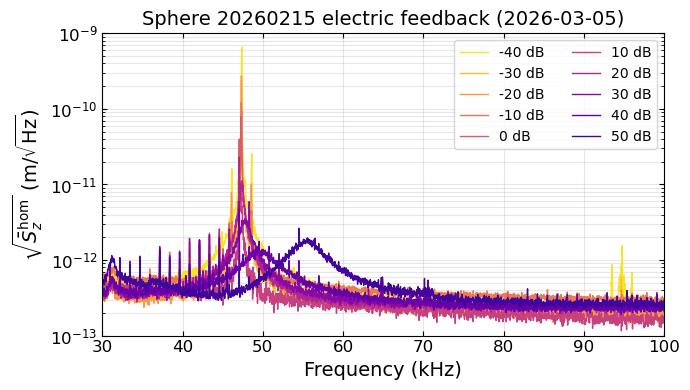

In [48]:
def make_label(folder_name):
    tag = folder_name.replace('20260305_d_', '')
    if tag == '10db_40db':
        return '50 dB'
    return tag.replace('db', ' dB')


plot_folders = [fn for fn in folder_names if 'pll' not in fn and '10db_40db' not in fn]
plot_folders += [fn for fn in folder_names if '10db_40db' in fn]

colors = plt.colormaps['plasma'](np.linspace(0.95, 0.1, len(plot_folders)))
fig, ax = plt.subplots(figsize=(7, 4))

for i, fn in enumerate(plot_folders):
    ff, pp = psds[fn]
    label = make_label(fn)
    ax.plot(ff / 1e3, np.sqrt(pp * c_mv**2), lw=1, label=label, color=colors[i], linestyle='-')

ax.set_yscale('log')
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel(r'$\sqrt{\bar{S}^{\mathrm{hom}}_z}$ (m/$\sqrt{\mathrm{Hz}}$)')
ax.set_title('Sphere 20260215 electric feedback (2026-03-05)')
ax.set_xlim(30, 100)
ax.set_ylim(1e-13, 1e-9)

ax.legend(fontsize=10, ncol=2)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

Resonance: f = 47.301 kHz,  phase = -227.6 deg


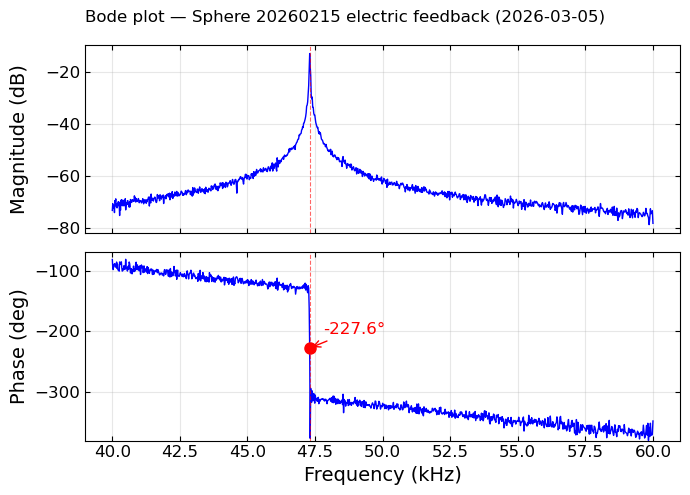

In [25]:
bode_file = '/Volumes/LaCie/electric_feedback/sphere_20260215/MokuFrequencyResponseAnalyzerSlot3Data_20260305_172513_Traces.csv'
bode_data = np.genfromtxt(bode_file, delimiter=',', comments='%')
bode_freq, bode_mag_db, bode_phase_deg = bode_data[:, 0], bode_data[:, 1], bode_data[:, 2]

# Resonance from magnitude peak
i_res        = np.argmax(bode_mag_db)
f_res        = bode_freq[i_res]
phase_at_res = bode_phase_deg[i_res]
print(f'Resonance: f = {f_res/1e3:.3f} kHz,  phase = {phase_at_res:.1f} deg')

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)

axes[0].plot(bode_freq / 1e3, bode_mag_db, lw=1, color='b')
axes[0].axvline(f_res / 1e3, color='r', lw=0.8, ls='--', alpha=0.6)
axes[0].set_ylabel('Magnitude (dB)')
axes[0].grid(True, which='both', alpha=0.3)

axes[1].plot(bode_freq / 1e3, bode_phase_deg, lw=1, color='b')
axes[1].axvline(f_res / 1e3, color='r', lw=0.8, ls='--', alpha=0.6)
axes[1].plot(f_res / 1e3, phase_at_res, 'o', color='r', ms=8, zorder=5)
axes[1].annotate(f'{phase_at_res:.1f}°',
                 xy=(f_res / 1e3, phase_at_res),
                 xytext=(10, 10), textcoords='offset points',
                 color='r', fontsize=12,
                 arrowprops=dict(arrowstyle='->', color='r', lw=1))
axes[1].set_ylabel('Phase (deg)')
axes[1].set_xlabel('Frequency (kHz)')
axes[1].set_ylim(-380, -70)
axes[1].grid(True, which='both', alpha=0.3)

fig.suptitle('Bode plot — Sphere 20260215 electric feedback (2026-03-05)')
fig.tight_layout()
fig.align_labels()
plt.show()

In [45]:
from scipy.optimize import curve_fit

# ---------------------------------------------------------------------------
# PSD model functions (Appendix IV, arXiv:2103.03853)
# ---------------------------------------------------------------------------

def _psd_inloop(ff, f_z, gamma_eff, gamma_m, A_FF, S_imp):
    omega   = 2 * np.pi * ff
    omega_z = 2 * np.pi * f_z
    D_eff = (omega_z**2 - omega**2)**2 + (gamma_eff * omega)**2
    D_m   = (omega_z**2 - omega**2)**2 + (gamma_m   * omega)**2
    return A_FF / D_eff + S_imp * D_m / D_eff


def _psd_actual(ff, f_z, gamma_eff, gamma_m, A_FF, S_imp):
    omega   = 2 * np.pi * ff
    omega_z = 2 * np.pi * f_z
    D_eff = (omega_z**2 - omega**2)**2 + (gamma_eff * omega)**2
    return (A_FF + omega_z**2 * (gamma_eff - gamma_m)**2 * S_imp) / D_eff


# ---------------------------------------------------------------------------
# Fitting helpers
# ---------------------------------------------------------------------------

def _auto_p0(ff, pp, freq_band):
    """Rough initial parameter estimates from the PSD."""
    mask       = (ff >= freq_band[0]) & (ff <= freq_band[1])
    ff_b, pp_b = ff[mask], pp[mask]

    i_pk       = np.argmax(pp_b)
    f_z_init   = ff_b[i_pk]
    omega_z    = 2 * np.pi * f_z_init
    S_imp_init = np.percentile(pp_b, 10)
    peak_exc   = pp_b[i_pk] - S_imp_init

    half  = S_imp_init + peak_exc / 2
    above = np.where(pp_b > half)[0]
    df_fwhm = (ff_b[above[-1]] - ff_b[above[0]]) if len(above) >= 2 else 200.0
    gamma_eff_init = 2 * np.pi * df_fwhm

    A_FF_init = peak_exc * gamma_eff_init**2 * omega_z**2

    return dict(f_z=f_z_init, gamma_eff=gamma_eff_init, gamma_m=gamma_eff_init,
                A_FF=A_FF_init, S_imp=S_imp_init)


def _fit_reference_psd(ff, pp, freq_band, p0):
    """
    Fit the no-feedback (reference) PSD: Lorentzian + flat floor.
    Free params: f_z, γ_m, A_FF, S_imp.  Fit in log-space.
    """
    def model(ff, f_z, gamma_m, A_FF, S_imp):
        omega   = 2 * np.pi * ff
        omega_z = 2 * np.pi * f_z
        D = (omega_z**2 - omega**2)**2 + (gamma_m * omega)**2
        return A_FF / D + S_imp

    mask = (ff >= freq_band[0]) & (ff <= freq_band[1])
    ff_f, pp_f = ff[mask], pp[mask]
    p0_arr = [p0['f_z'], p0['gamma_eff'], p0['A_FF'], p0['S_imp']]

    bounds = (
        [0,       2 * np.pi,  0,      0     ],  # γ_m ≥ 2π rad/s ≈ 1 Hz
        [np.inf,  np.inf,     np.inf, np.inf],
    )

    popt, _ = curve_fit(
        lambda ff, f_z, gamma_m, A_FF, S_imp: np.log(model(ff, f_z, gamma_m, A_FF, S_imp)),
        ff_f, np.log(pp_f), p0=p0_arr, bounds=bounds, maxfev=50000,
    )
    return dict(f_z=popt[0], gamma_eff=popt[1], gamma_m=popt[1],
                A_FF=popt[2], S_imp=popt[3])


def _fit_feedback_psd(ff, pp, freq_band, p0, ref_params, noise_band=(110000, 120000)):
    """
    Estimate feedback PSD parameters without curve fitting:
      - S_imp : mean PSD in noise_band (well away from resonance)
      - f_z   : peak of floor-subtracted PSD within freq_band
      - γ_eff : FWHM of floor-subtracted PSD (γ_eff = 2π · FWHM_Hz)
      - γ_m, A_FF : fixed from ref_params
    """
    gamma_m = ref_params['gamma_m']
    A_FF    = ref_params['A_FF']

    noise_mask = (ff >= noise_band[0]) & (ff <= noise_band[1])
    S_imp = float(np.mean(pp[noise_mask]))

    mask = (ff >= freq_band[0]) & (ff <= freq_band[1])
    ff_b, pp_b = ff[mask], pp[mask]

    pp_exc  = pp_b - S_imp
    i_pk    = np.argmax(pp_exc)
    f_z     = ff_b[i_pk]
    peak    = pp_exc[i_pk]

    above = np.where(pp_exc > peak / 2)[0]
    if len(above) >= 2:
        df_fwhm = ff_b[above[-1]] - ff_b[above[0]]
    else:
        df_fwhm = p0['gamma_eff'] / (2 * np.pi)   # fallback to auto_p0 estimate
    gamma_eff = max(2 * np.pi * df_fwhm, gamma_m)

    return dict(f_z=f_z, gamma_eff=gamma_eff,
                gamma_m=gamma_m, A_FF=A_FF, S_imp=S_imp)


# ---------------------------------------------------------------------------
# n_bar computation
# ---------------------------------------------------------------------------

def _n_bar_from_params(params, mass, c_mv, freq_band, ff, pp):
    """
    Closed-form n̄ from fitted parameters (corrected for noise squashing).

        n̄ = c_mv² C / (8 z_zpf² γ_eff ω_z²) − 1/2
        C  = A_FF + ω_z²·(γ_eff − γ_m)²·S_imp
    """
    hbar    = 1.0545718e-34
    f_z     = params['f_z']
    omega_z = 2 * np.pi * f_z
    z_zpf   = np.sqrt(hbar / (2 * mass * omega_z))
    C       = params['A_FF'] + omega_z**2 * (params['gamma_eff'] - params['gamma_m'])**2 * params['S_imp']
    return c_mv**2 * C / (8 * z_zpf**2 * params['gamma_eff'] * omega_z**2) - 0.5


def _n_bar_raw_integral(ff, pp, mass, c_mv, freq_band):
    """
    n̄ from direct numerical integration of the raw measured PSD over freq_band.
    No model fitting — f_z estimated from the in-band peak.
    Biased low at high feedback gain (noise squashing not corrected).
    """
    hbar = 1.0545718e-34
    mask = (ff >= freq_band[0]) & (ff <= freq_band[1])
    ff_b, pp_b = ff[mask], pp[mask]

    f_z     = ff_b[np.argmax(pp_b)]
    omega_z = 2 * np.pi * f_z
    z_zpf   = np.sqrt(hbar / (2 * mass * omega_z))

    integrand = (1) * pp_b * c_mv**2 / (2 * z_zpf**2)

    return np.trapz(integrand, ff_b*2*np.pi) / (2 * np.pi) - 0.5


# ---------------------------------------------------------------------------
# Main function
# ---------------------------------------------------------------------------

def phonon_occupancy_from_psd(ff, pp, mass, c_mv, freq_band,
                               ref_params=None, correct_inloop=True,
                               noise_band=(110000, 120000),
                               return_fit=False):
    """
    Compute phonon occupancy from a measured in-loop homodyne PSD.

    correct_inloop=True  (default):
        Two-step approach (Appendix IV, arXiv:2103.03853):
        - ref_params=None : fit reference PSD (Lorentzian + floor, log-space)
                            to get γ_m and A_FF
        - ref_params given: estimate γ_eff from FWHM of floor-subtracted PSD;
                            S_imp measured from noise_band; γ_m, A_FF fixed.
        Phonon number from closed-form integral of corrected actual PSD.

    correct_inloop=False:
        Direct numerical integration of raw measured PSD.  No fitting.
        Biased low at high gain (noise squashing uncorrected).

    Parameters
    ----------
    ff, pp         : frequency [Hz] and one-sided PSD [V²/Hz]
    mass           : sphere mass [kg]
    c_mv           : calibration [m/V]
    freq_band      : (f_lo, f_hi) [Hz]  band around resonance
    ref_params     : dict from a corrected call with return_fit=True
    correct_inloop : bool
    noise_band     : (f_lo, f_hi) [Hz]  flat region to measure S_imp
                     (only used for feedback PSDs, default 110–120 kHz)
    return_fit     : bool  — if True, also return params dict (or None)
    """
    if not correct_inloop:
        n_bar = _n_bar_raw_integral(ff, pp, mass, c_mv, freq_band)
        return (n_bar, None) if return_fit else n_bar

    p0 = _auto_p0(ff, pp, freq_band)
    if ref_params is None:
        params = _fit_reference_psd(ff, pp, freq_band, p0)
    else:
        p0.update(ref_params)
        params = _fit_feedback_psd(ff, pp, freq_band, p0, ref_params, noise_band=noise_band)

    n_bar = _n_bar_from_params(params, mass, c_mv, freq_band, ff, pp)

    return (n_bar, params) if return_fit else n_bar


# ---------------------------------------------------------------------------
# Usage
# ---------------------------------------------------------------------------

SPHERE_RADIUS  = 50e-9    # m
SPHERE_DENSITY = 2000.0   # kg/m³  (amorphous SiO₂)
sphere_mass = (4/3) * np.pi * SPHERE_RADIUS**3 * SPHERE_DENSITY
FREQ_BAND   = (30000, 80000)
NOISE_BAND  = (110000, 120000)  # Hz — flat region for S_imp measurement

# Step 1: fit reference (no-feedback) spectrum
ref_ff, ref_pp = psds['20260305_d_pllonly']
n_ref, ref_params = phonon_occupancy_from_psd(
    ref_ff, ref_pp, sphere_mass, c_mv, FREQ_BAND, return_fit=True
)
print(f"Reference (pllonly): n̄ = {n_ref:.0f}")
print(f"  f_z      = {ref_params['f_z']/1e3:.3f} kHz")
print(f"  γ_m/(2π) = {ref_params['gamma_m']/(2*np.pi):.1f} Hz")
print(f"  A_FF     = {ref_params['A_FF']:.3e}")
print(f"  S_imp    = {ref_params['S_imp']:.3e} V²/Hz")
print()

# Step 2: all PSDs
print(f"{'Folder':<35}  {'n̄ (corrected)':>15}  {'n̄ (raw)':>10}  {'γ_eff/(2π) [Hz]':>18}  {'f_z [kHz]':>12}")
print("-" * 95)
for fn, (ff, pp) in psds.items():
    is_ref = (fn == '20260305_d_pllonly')
    n_corr, params = phonon_occupancy_from_psd(
        ff, pp, sphere_mass, c_mv, FREQ_BAND,
        ref_params=(None if is_ref else ref_params),
        noise_band=NOISE_BAND,
        correct_inloop=True, return_fit=True,
    )
    n_raw = phonon_occupancy_from_psd(
        ff, pp, sphere_mass, c_mv, FREQ_BAND,
        correct_inloop=False,
    )
    gamma_eff_hz = params['gamma_eff'] / (2 * np.pi)
    print(f"{fn:<35}  {n_corr:>15.1f}  {n_raw:>10.1f}"
          f"  {gamma_eff_hz:>18.1f}  {params['f_z']/1e3:>12.3f}")

Reference (pllonly): n̄ = 45180
  f_z      = 47.409 kHz
  γ_m/(2π) = 1.9 Hz
  A_FF     = 1.807e+08
  S_imp    = 1.061e-13 V²/Hz

Folder                                n̄ (corrected)    n̄ (raw)     γ_eff/(2π) [Hz]     f_z [kHz]
-----------------------------------------------------------------------------------------------
20260305_d_-40db                              2202.0     77054.8                38.1        47.379
20260305_d_-30db                              4408.1      9037.3                19.1        47.340
20260305_d_-20db                              4408.1     10148.5                19.1        47.340
20260305_d_-10db                              1102.1      4008.1                76.3        47.321
20260305_d_0db                                1470.2      1953.3                57.2        47.302
20260305_d_10db                                316.2        84.1               267.0        47.073
20260305_d_10db_40db                            36.4        78.2              2021

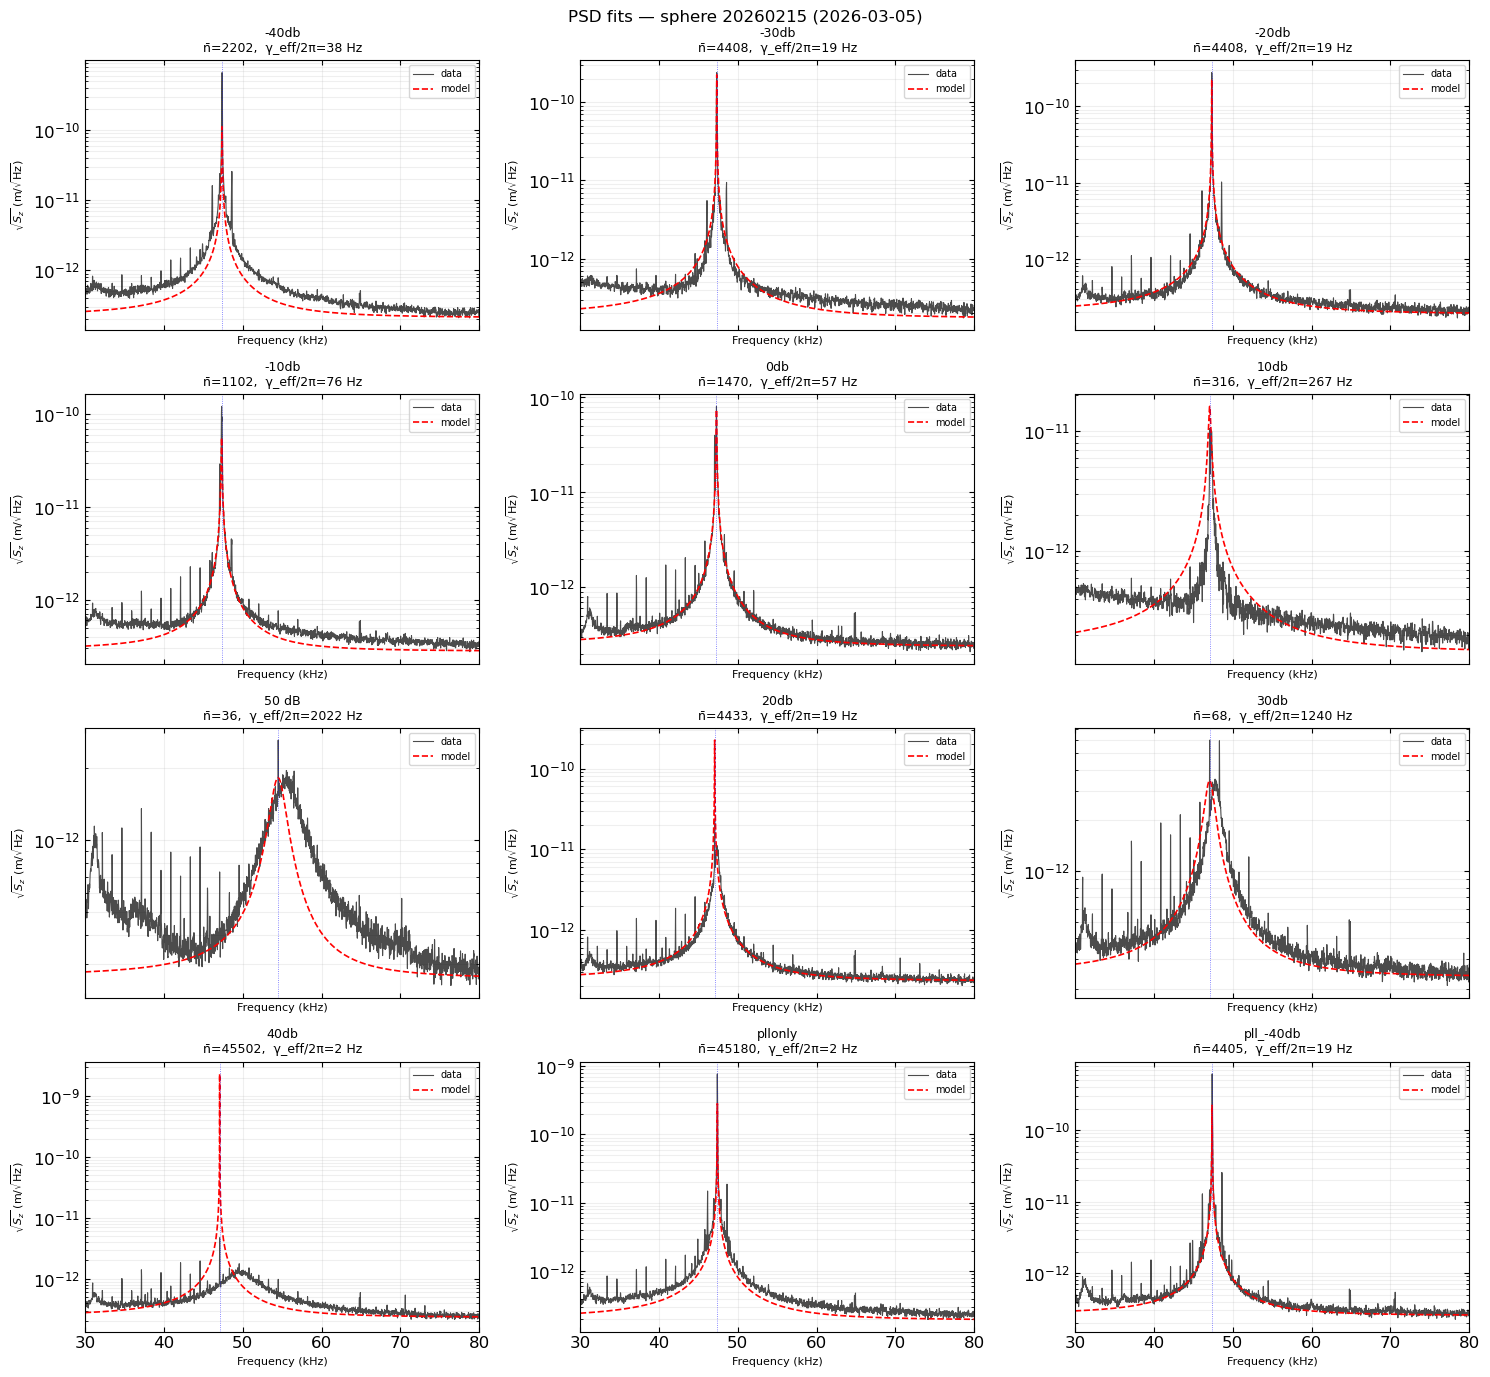

In [46]:
# ---------------------------------------------------------------------------
# Plot measured PSDs with model overlays
# ---------------------------------------------------------------------------

ncols = 3
nrows = int(np.ceil(len(psds) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharex=True)
axes = axes.ravel()

for ax, (fn, (ff, pp)) in zip(axes, psds.items()):
    is_ref = (fn == '20260305_d_pllonly')

    n_bar_val, fit_params = phonon_occupancy_from_psd(
        ff, pp, sphere_mass, c_mv, FREQ_BAND,
        ref_params=(None if is_ref else ref_params),
        noise_band=NOISE_BAND,
        correct_inloop=True, return_fit=True,
    )

    mask = (ff >= FREQ_BAND[0]) & (ff <= FREQ_BAND[1])
    ff_b = ff[mask]

    ax.semilogy(ff_b / 1e3, np.sqrt(pp[mask] * c_mv**2), color='k', lw=0.8,
                alpha=0.7, label='data')

    f_z       = fit_params['f_z']
    gamma_eff = fit_params['gamma_eff']
    gamma_m   = fit_params['gamma_m']
    A_FF      = fit_params['A_FF']
    S_imp     = fit_params['S_imp']

    if is_ref:
        omega   = 2 * np.pi * ff_b
        omega_z = 2 * np.pi * f_z
        D = (omega_z**2 - omega**2)**2 + (gamma_m * omega)**2
        pp_model = A_FF / D + S_imp
    else:
        pp_model = _psd_inloop(ff_b, f_z, gamma_eff, gamma_m, A_FF, S_imp)

    ax.semilogy(ff_b / 1e3, np.sqrt(pp_model * c_mv**2), color='r', lw=1.2,
                ls='--', label='model')

    label = fn.replace('20260305_d_', '')
    if label == '10db_40db':
        label = '50 dB'
    ax.set_title(f'{label}\nn̄={n_bar_val:.0f},  γ_eff/2π={gamma_eff/(2*np.pi):.0f} Hz',
                 fontsize=9)
    ax.axvline(f_z / 1e3, color='b', lw=0.6, ls=':', alpha=0.6)
    ax.set_xlim(np.array(FREQ_BAND) / 1e3)
    ax.grid(True, which='both', alpha=0.2)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_ylabel(r'$\sqrt{S_z}$ (m/$\sqrt{\mathrm{Hz}}$)', fontsize=8)
    ax.set_xlabel('Frequency (kHz)', fontsize=8)

for ax in axes[len(psds):]:
    ax.set_visible(False)

fig.suptitle('PSD fits — sphere 20260215 (2026-03-05)', fontsize=12)
fig.tight_layout()
plt.show()

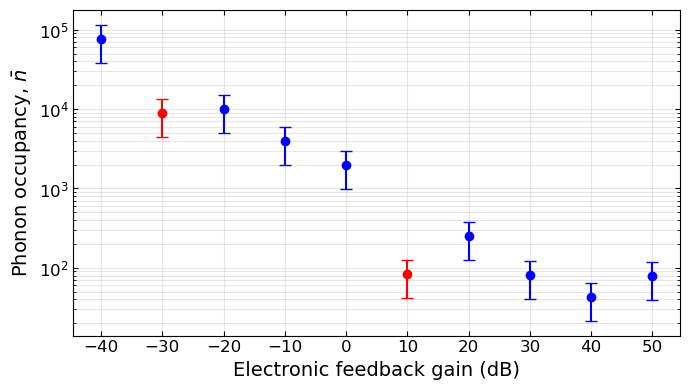

In [47]:
def _gain_db(folder_name):
    tag = folder_name.replace('20260305_d_', '')
    if tag == '10db_40db':
        return 50.0
    return float(tag.replace('db', ''))

PROBLEMATIC_GAINS = {-30.0, 10.0}

# Collect corrected n_bar for non-pll folders
gain_nbar = {}
for fn, (ff, pp) in psds.items():
    if 'pll' in fn:
        continue
    n_bar_c = phonon_occupancy_from_psd(
        ff, pp, sphere_mass, c_mv, FREQ_BAND,
        ref_params=ref_params, correct_inloop=False,
    )
    gain_nbar[_gain_db(fn)] = n_bar_c

gains  = np.array(sorted(gain_nbar))
n_bars = np.array([gain_nbar[g] for g in gains])
n_errs = 0.5 * np.abs(n_bars)

fig, ax = plt.subplots(figsize=(7, 4))
for g, n, e in zip(gains, n_bars, n_errs):
    color = 'r' if g in PROBLEMATIC_GAINS else 'b'
    ax.errorbar(g, n, yerr=e, fmt='o', capsize=4,
                color=color, ecolor=color, lw=1.5, ms=6)

ax.set_yscale('log')
ax.set_xlabel('Electronic feedback gain (dB)')
ax.set_ylabel(r'Phonon occupancy, $\bar{n}$')
ax.grid(True, which='both', alpha=0.3)
ax.set_xticks(gains)
fig.tight_layout()
plt.show()